In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename



In [2]:
# Read in the current baseline
db_file = "comp_survey_v5.3.0_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)


In [3]:
is_template = ["template" in note for note in visits_array["scheduler_note"]]

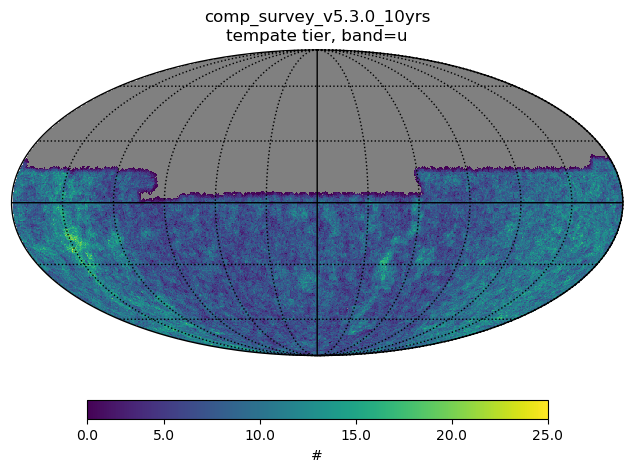

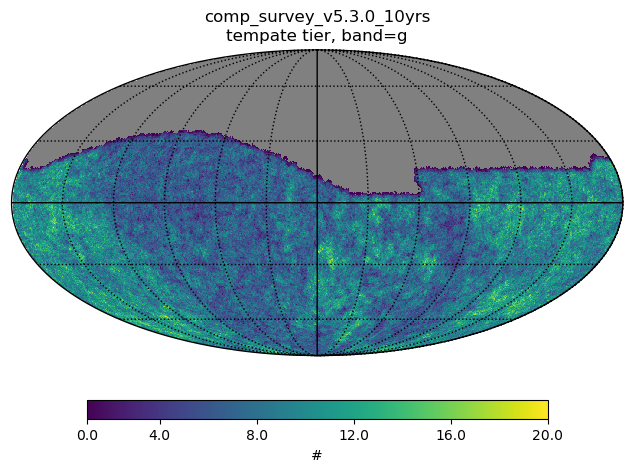

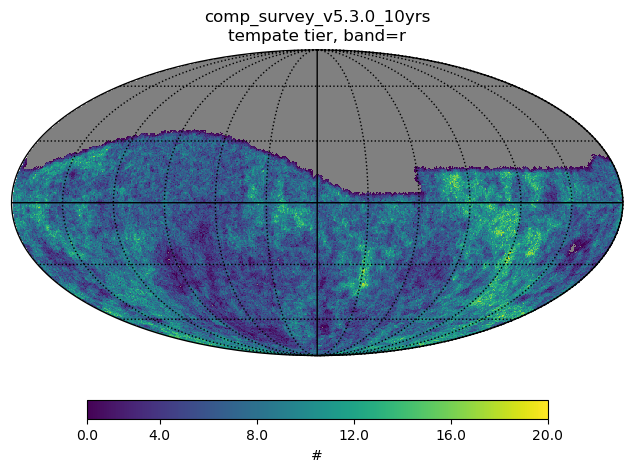

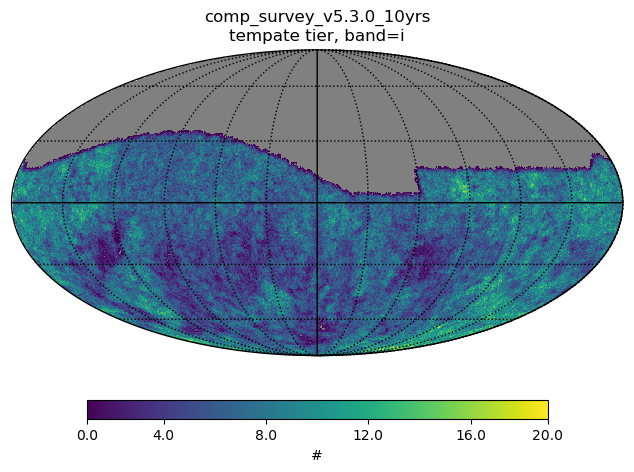

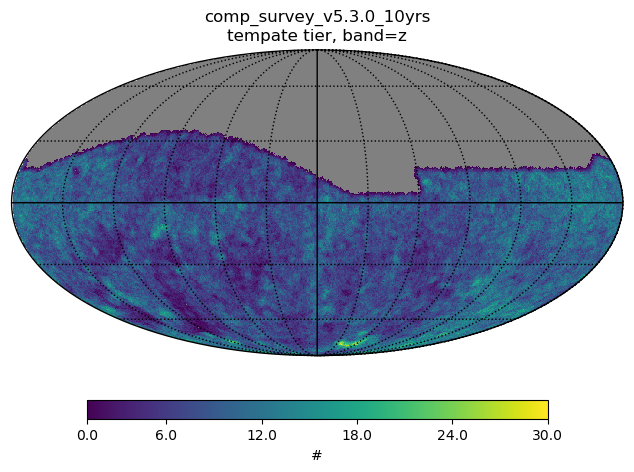

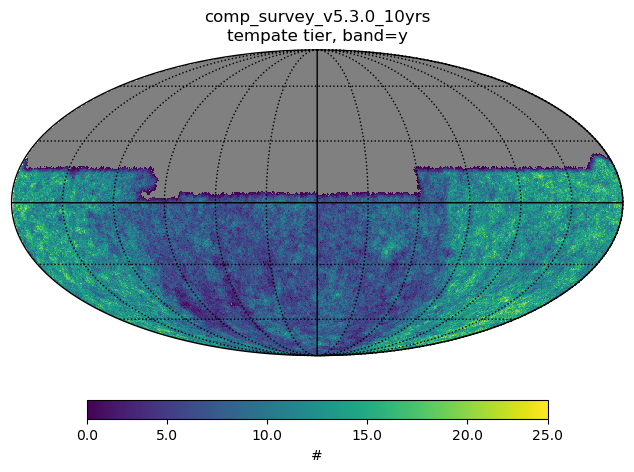

In [4]:
for bandname in 'ugrizy':
    info = {"run_name": run_name}
    sub_data = visits_array[np.where((visits_array["band"] == bandname) & (is_template))]
    info['observations_subset'] = "tempate tier, band=%s" % (bandname)
    sl = maf.Slicer()
    metric = maf.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)
    pm = maf.PlotMoll(info=info)
    fig = pm(hp_array)

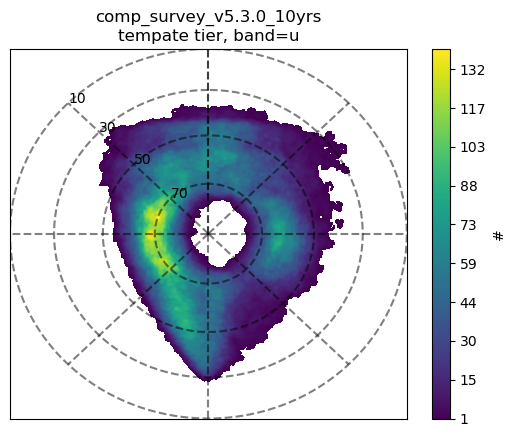

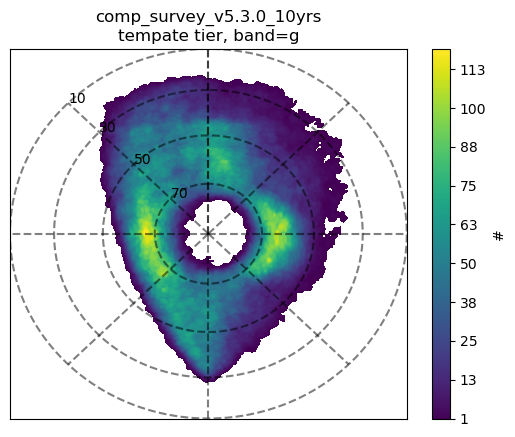

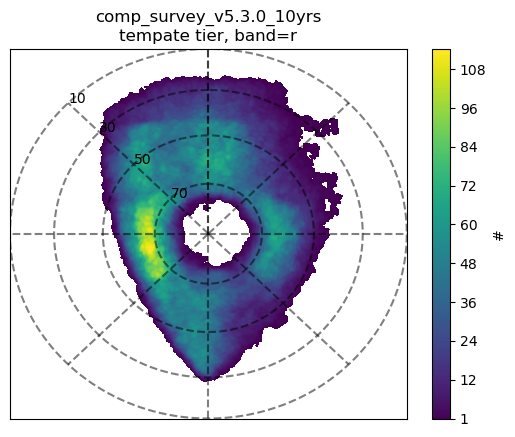

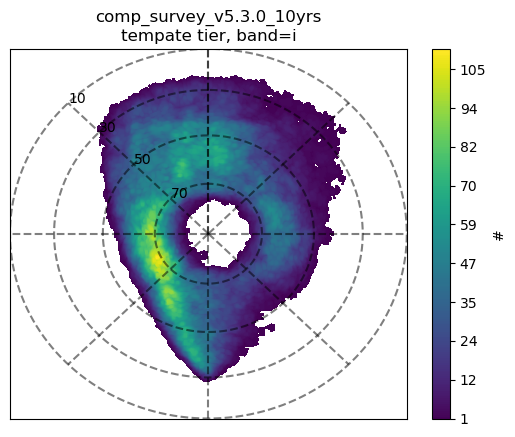

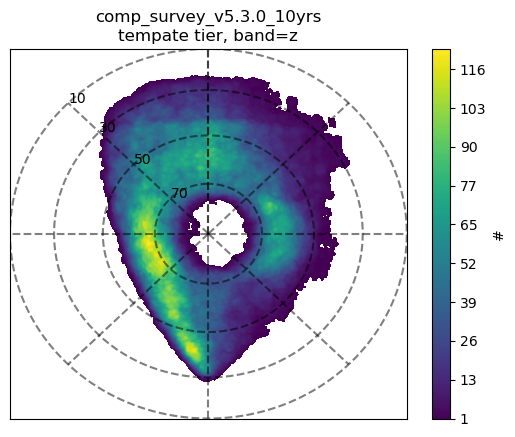

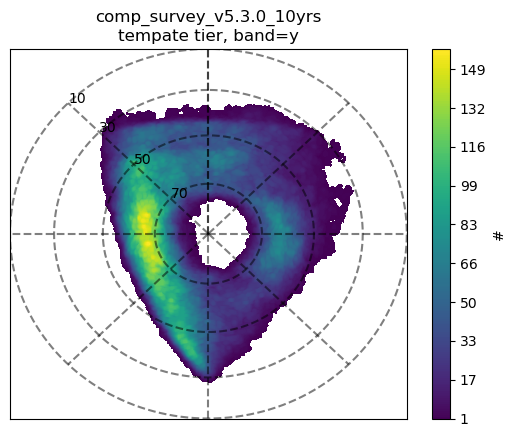

In [7]:
for bandname in 'ugrizy':
    info = {"run_name": run_name}
    sub_data = visits_array[np.where((visits_array["band"] == bandname) & (is_template))]
    info['observations_subset'] = "tempate tier, band=%s" % (bandname)
    sl = maf.Slicer(lon_col="azimuth", lat_col="altitude", nside=64)
    metric = maf.CountMetric()
    # Run the metics through the slicer
    hp_array, info = sl(sub_data, metric, info=info)
    pl = maf.PlotLambert(info=info)
    fig = pl(hp_array)